# **Detector Variance Analysis | Baseline VS MaskShift**

In [1]:
from pathlib import Path
from typing import Any

import numpy as np
from numpy.typing import NDArray

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [2]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "CameraGeometry"

DATA_FITS_bline: str = "baseline_2-50keV_1ks"
RUN_ID_bline: str = 'baseline_wcxb'

DATA_FITS_mshift: str = "mask_Z2arcmin_2-50keV_1ks"
RUN_ID_mshift: str = 'mask_Z2arcmin_wcxb'

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

VIGNETTING: bool = True
PSFY: bool = mgm.config_psfy_flag(DATASET)

E_min, E_max = 2.0, 50.0           # [keV]
# exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = [
    #     CoordEquatorial(318.950871147977, -51.1920260999562),   # s0
    #     CoordEquatorial(296.376333558386, 5.25424886863538),    # s1
    #     CoordEquatorial(236.423666441614, 5.25424886863538),    # s2
    #     CoordEquatorial(213.849128852023, -51.1920260999562),   # s3
    #     CoordEquatorial(286.170341181402, -42.2037736309785),   # s4
    #     CoordEquatorial(281.331753525598, -13.4867719837475),   # s5
    #     CoordEquatorial(251.468246474402, -13.4867719837475),   # s6
    #     CoordEquatorial(246.629658818598, -42.2037736309785),   # s7
    #     CoordEquatorial(266.4, -28.94),                         # s8
    # ]
exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = None

In [3]:
MASK_PATH, SIMUL_DATA_PATH_bline, SAVE_PATH_bline = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_bline,
    runID=RUN_ID_bline,
)
_, SIMUL_DATA_PATH_mshift, SAVE_PATH_mshift = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_mshift,
    runID=RUN_ID_mshift,
)
# OUT_RESULTS_PATH = '/home/edoardo/Desktop'
OUT_RESULTS_PATH = '/mnt/d/PhD_AASS/Coding/Images_fits'

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y, mask_pattern_shift=2.0)
wfm_noshift: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

In [4]:
from astropy.io import fits
from bloodmoon.mask import variance

def load_fits_img(filepath: Path, *ext: int) -> list[NDArray]:
    """Open FITS and retrieve ImageHDU data following given `ext` order."""
    objs: list[NDArray] = []
    with fits.open(filepath) as hdu:
        for e in ext: objs.append(hdu[e].data)
    return objs[0] if len(ext) == 1 else objs

detector_bline = load_fits_img(f"{SAVE_PATH_bline}/SIMUL_sky.fits", 3)
varmap_bline = variance(wfm_noshift, detector_bline)

detector_mshift = load_fits_img(f"{SAVE_PATH_mshift}/SIMUL_sky.fits", 3)
varmap_mshift = variance(wfm, detector_mshift)

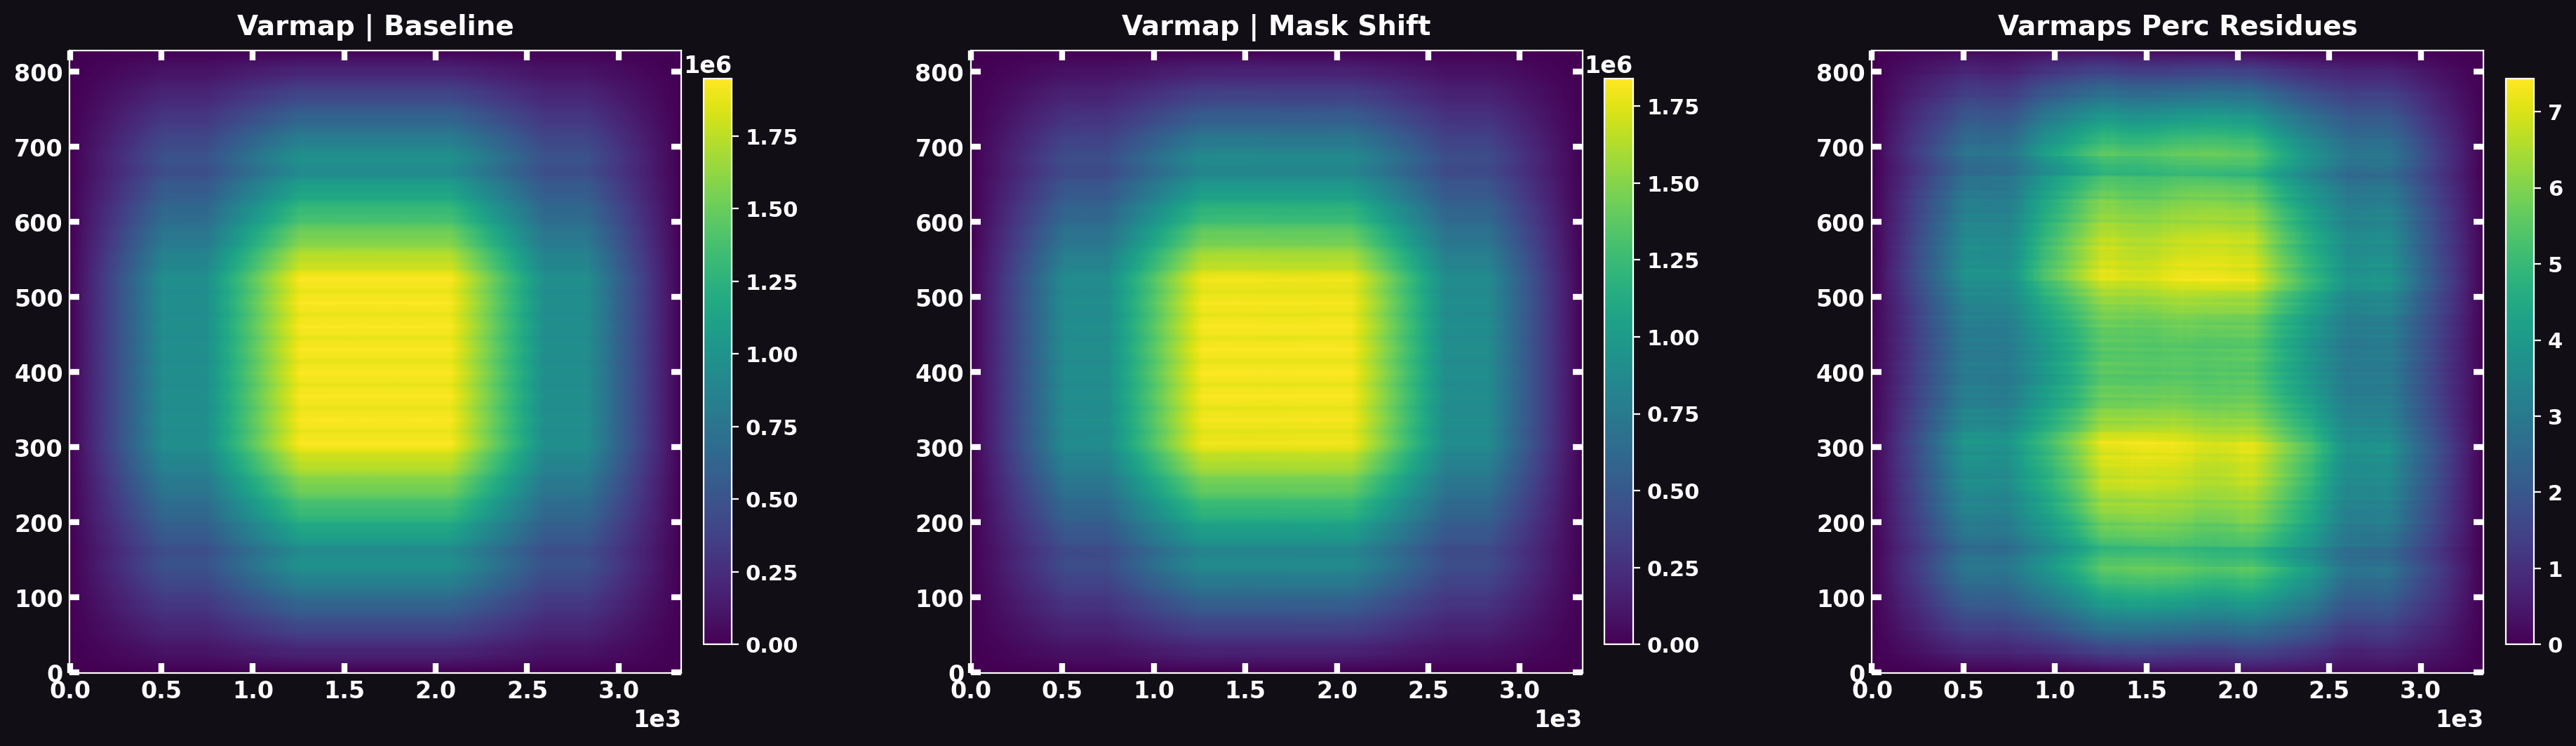

In [6]:
KWS = {'aspect': wfm.shape_detector[1] / wfm.shape_detector[0]}
ds.image_plot(
    dmaps=(
        ds.map4image(varmap_bline, title='Varmap | Baseline', img_kwargs=KWS),
        ds.map4image(varmap_mshift, title='Varmap | Mask Shift', img_kwargs=KWS),
        ds.map4image((varmap_bline - varmap_mshift) * 100 / varmap_bline.max(), title='Varmaps Perc Residues', img_kwargs=KWS),
    ),
    ncols=3,
)